In [65]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 785741 entries, 0 to 785740
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   job_title_short        785741 non-null  object        
 1   job_title              785740 non-null  object        
 2   job_location           784696 non-null  object        
 3   job_via                785733 non-null  object        
 4   job_schedule_type      773074 non-null  object        
 5   job_work_from_home     785741 non-null  bool          
 6   search_location        785741 non-null  object        
 7   job_posted_date        785741 non-null  datetime64[ns]
 8   job_no_degree_mention  785741 non-null  bool          
 9   job_health_insurance   785741 non-null  bool          
 10  job_country            785692 non-null  object        
 11  salary_rate            33067 non-null   object        
 12  salary_year_avg        22003 non-null   floa

In [6]:
df_exploded=df.explode('job_skills')

<Axes: xlabel='job_skills'>

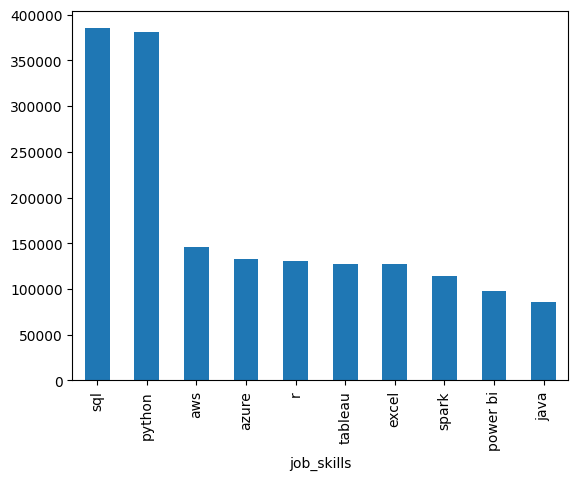

In [29]:
df_exploded['job_skills'].value_counts().head(10).plot(kind='bar')

In [12]:
skills_count=df_exploded.groupby(['job_skills','job_title_short']).size()

In [14]:
type(skills_count)

pandas.core.series.Series

In [15]:
df_skills_count=skills_count.reset_index(name='skill_count')

In [17]:
df_skills_count=df_skills_count.sort_values(by='skill_count',ascending=False)

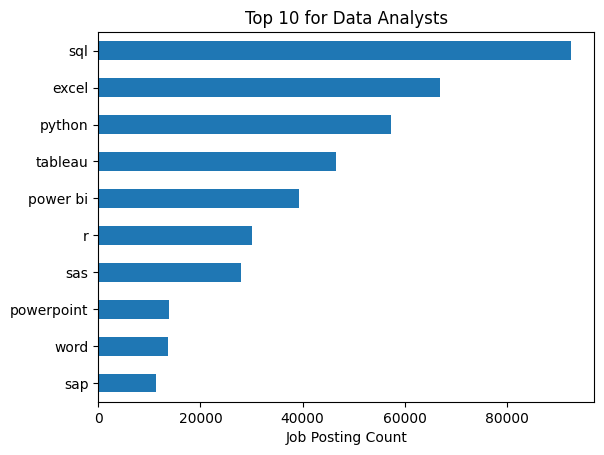

In [30]:
job_title='Data Analyst'
top_skills=10
df_skills_final=df_skills_count[df_skills_count['job_title_short']==job_title].head(top_skills)
df_skills_final.plot(kind='barh',x='job_skills',y='skill_count')
plt.gca().invert_yaxis()
plt.title(f'Top {top_skills} for {job_title}s')
plt.xlabel('Job Posting Count')
plt.ylabel('')
plt.legend().set_visible(False)

<span style = "color:green; font-width:bold ;font-size:32px;"> Practise Prompts </span>

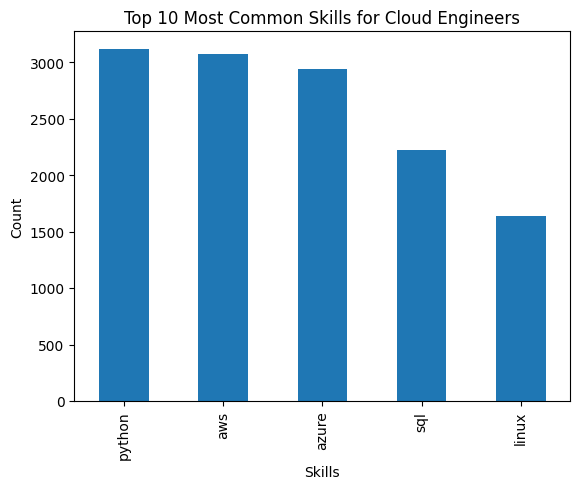

In [73]:
# Problem
# Pandas Explode
# Problem Statement:
# Using the ast library, clean up the job_skills column to be of the list data type in preparation for exploding this column.
# NOTE: For future problems, it'll be assumed that you have done this step in preparation for exploding this column.
# Explode the job_skills column in the DataFrame and create a bar plot using pandas of the top 10 most common skills for Cloud Engineer.
# Add labels for the x-axis (label as 'Skills'), y-axis (label as 'Count') and 
# a title (set as 'Top 10 Most Common Skills for Cloud Engineers') for the plot.


df_explode1=df[df['job_title_short'] == 'Cloud Engineer']

df_explode1=df_explode1.explode('job_skills')


df_explode1_count=df_explode1['job_skills'].value_counts().head()

df_explode1_count.plot(kind='bar')
plt.xlabel('Skills')
plt.ylabel('Count')
plt.title('Top 10 Most Common Skills for Cloud Engineers')
plt.show()





In [74]:
# Problem Statement:
# Explode the job_skills column in the DataFrame and calculate the average salary for each skill. 
# Display the top 5 skills with the highest average salary.
df_exploded2 = df.explode('job_skills')

df_avg_salary=df_exploded2.groupby('job_skills')['salary_year_avg'].mean().reset_index()

df_avg_salary = df_avg_salary.sort_values(by='salary_year_avg', ascending=False).head()

df_avg_salary


,job_skills,salary_year_avg
46,debian,196500.000000
177,ringcentral,182500.000000
114,lua,170500.000000
126,mongo,169526.929749
54,dplyr,160667.210526


In [79]:
# Problem Statement:
# Explode the job_skills column in the DataFrame and calculate the number of unique skills for each job posting. 
# Display the first 5 rows of the resulting DataFrame with a new column num_unique_skills.

# Hint:
# Use the explode() function on the job_skills column, then group by job_title_short and 
# use nunique() to count the number of unique skills for each job posting.

df_exploded4 = df.explode('job_skills')
unique_skills_count = df_exploded.groupby('job_title_short')['job_skills'].nunique().reset_index()
unique_skills_count.columns = ['job_title_short', 'num_unique_skills']
unique_skills_count.head()


,job_title_short,num_unique_skills
0,Business Analyst,223
1,Cloud Engineer,213
2,Data Analyst,235
3,Data Engineer,239
4,Data Scientist,237
